# **Lab 2:**

Базові алгоритми навчання без учителя та обробка текстових даних (Scikit-learn lib)

Виконала: Балацька Вікторія ФІ-52мн

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# **Завдання 1:**
Зниження розмірності та візуалізація даних

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns

Завантаження датасету

In [3]:
data_frame = pd.read_csv("ObesityDataSet.csv")
data_frame

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


Виконуємо стандартну обробку датасету: перейменували колонки, виділили цільову змінну, а категоріальні текстові значення (тип транспорту, частоту прийому їжі, споживання алкоголю, «так/ні», стать) перетворили на числові коди.

In [4]:
rename_map = {
    "family_history_with_overweight": "FAM_OW",
    "NObeyesdad": "Obes_level"
}
data_frame = data_frame.rename(columns=rename_map)

TARGET_VAR = "Obes_level"
OTHER_FEATURES = [col for col in data_frame.columns if col != TARGET_VAR]

mobility_map = {
    'Walking': 0.0,
    'Bike': 0.1,
    'Public_Transportation': 0.4,
    'Motorbike': 0.6,
    'Automobile': 1.0
}
data_frame["MTRANS"] = data_frame["MTRANS"].map(mobility_map)

mobility_map = {
    'Always': 1.0,
    'Frequently': 0.66,
    'no': 0.0,
    'Sometimes': 0.33
}
data_frame['CAEC'] = data_frame['CAEC'].map(mobility_map)
data_frame['CALC'] = data_frame['CALC'].map(mobility_map)

mobility_map = {
    'yes': 1.0,
    'no': 0.0
}

gender_map = {
    'Female': 1.0,
    'Male': 0.0
}

data_frame['FAM_OW'] = data_frame['FAM_OW'].map(mobility_map)
data_frame['FAVC'] = data_frame['FAVC'].map(mobility_map)
data_frame['SCC'] = data_frame['SCC'].map(mobility_map)
data_frame['SMOKE'] = data_frame['SMOKE'].map(mobility_map)
data_frame['Gender'] = data_frame['Gender'].map(gender_map)

data_frame


,Gender,Age,Height,Weight,FAM_OW,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obes_level
0,1.0,21.000000,1.620000,64.000000,1.0,0.0,2.0,3.0,0.33,0.0,2.000000,0.0,0.000000,1.000000,0.00,0.4,Normal_Weight
1,1.0,21.000000,1.520000,56.000000,1.0,0.0,3.0,3.0,0.33,1.0,3.000000,1.0,3.000000,0.000000,0.33,0.4,Normal_Weight
2,0.0,23.000000,1.800000,77.000000,1.0,0.0,2.0,3.0,0.33,0.0,2.000000,0.0,2.000000,1.000000,0.66,0.4,Normal_Weight
3,0.0,27.000000,1.800000,87.000000,0.0,0.0,3.0,3.0,0.33,0.0,2.000000,0.0,2.000000,0.000000,0.66,0.0,Overweight_Level_I
4,0.0,22.000000,1.780000,89.800000,0.0,0.0,2.0,1.0,0.33,0.0,2.000000,0.0,0.000000,0.000000,0.33,0.4,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,1.0,20.976842,1.710730,131.408528,1.0,1.0,3.0,3.0,0.33,0.0,1.728139,0.0,1.676269,0.906247,0.33,0.4,Obesity_Type_III
2107,1.0,21.982942,1.748584,133.742943,1.0,1.0,3.0,3.0,0.33,0.0,2.005130,0.0,1.341390,0.599270,0.33,0.4,Obesity_Type_III
2108,1.0,22.524036,1.752206,133.689352,1.0,1.0,3.0,3.0,0.33,0.0,2.054193,0.0,1.414209,0.646288,0.33,0.4,Obesity_Type_III
2109,1.0,24.361936,1.739450,133.346641,1.0,1.0,3.0,3.0,0.33,0.0,2.852339,0.0,1.139107,0.586035,0.33,0.4,Obesity_Type_III


Відокремимо дані та мітки. Перетворимо дані за допомогою StandardScaler

In [5]:
X = data_frame.drop(columns=[TARGET_VAR])
y = data_frame[TARGET_VAR]

X.dtypes

,0
Gender,float64
Age,float64
Height,float64
Weight,float64
FAM_OW,float64
FAVC,float64
FCVC,float64
NCP,float64
CAEC,float64
SMOKE,float64


In [6]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [7]:
scaler

StandardScaler()

In [8]:
X_std

array([[ 1.01191369, -0.52212439, -0.87558934, ...,  0.56199675,
        -1.41902432, -0.45610306],
       [ 1.01191369, -0.52212439, -1.94759928, ..., -1.08062463,
         0.52106736, -0.45610306],
       [-0.98822657, -0.20688898,  1.05402854, ...,  0.56199675,
         2.46115904, -0.45610306],
       ...,
       [ 1.01191369, -0.28190933,  0.54167211, ..., -0.01901815,
         0.52106736, -0.45610306],
       [ 1.01191369,  0.00777624,  0.40492652, ..., -0.11799101,
         0.52106736, -0.45610306],
       [ 1.01191369, -0.10211908,  0.39834438, ...,  0.09243207,
         0.52106736, -0.45610306]])

Розглянемо дисперсії по кожній змінній (Аналіз основних компонент або PCA)

In [9]:
pca = PCA()
X_pca = pca.fit_transform(X_std)

In [10]:
pca

PCA()

In [11]:
X_pca

array([[-1.98070872e+00,  3.45046254e-02, -1.79133786e-03, ...,
        -1.57868382e-01,  5.49138173e-01,  4.28304952e-01],
       [-2.59669083e+00, -9.84788573e-01,  5.29992637e-01, ...,
        -1.09519985e+00, -3.35664925e-01, -7.61954269e-01],
       [ 4.76860853e-01, -1.80682875e+00,  8.78070903e-01, ...,
        -6.63910394e-01, -3.06616692e-01,  4.02252753e-01],
       ...,
       [ 1.16554516e+00, -2.10693267e-01, -1.85291905e+00, ...,
         5.56492925e-01,  5.81397649e-01, -6.46106222e-02],
       [ 1.40824726e+00, -1.19548728e-01, -2.06452531e+00, ...,
         6.78582915e-01,  4.21081878e-01, -4.41681041e-02],
       [ 1.36945518e+00, -1.94938669e-01, -2.15708089e+00, ...,
         6.48760237e-01,  4.69646553e-01, -6.49158337e-02]])

Частка поясненої дисперсії кожною компонентою

In [12]:
exp_var_pca = pca.explained_variance_ratio_
exp_var_pca

array([0.16287857, 0.11745648, 0.09345239, 0.08459325, 0.07028906,
       0.06660752, 0.06140003, 0.05464879, 0.0513149 , 0.04927885,
       0.04749723, 0.04265618, 0.03761426, 0.02520964, 0.02126444,
       0.01383842])

Кумулятивна сума поясненої дисперсії

In [13]:
cum_sum_eigenvalues = np.cumsum(exp_var_pca)
cum_sum_eigenvalues

array([0.16287857, 0.28033505, 0.37378744, 0.45838069, 0.52866975,
       0.59527727, 0.6566773 , 0.7113261 , 0.76264099, 0.81191984,
       0.85941706, 0.90207324, 0.9396875 , 0.96489714, 0.98616158,
       1.        ])

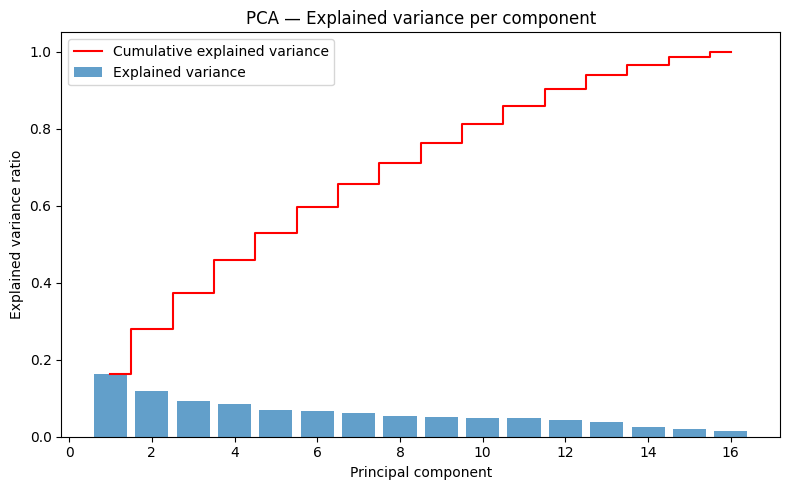

In [14]:
plt.figure(figsize=(8,5))

plt.bar(range(1, len(exp_var_pca)+1), exp_var_pca,
        align='center', alpha=0.7, label='Explained variance')

plt.step(range(1, len(cum_sum_eigenvalues)+1), cum_sum_eigenvalues,
         where='mid', color='red', label='Cumulative explained variance')

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component')
plt.title('PCA — Explained variance per component')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Застосуємо PCA, щоб знизити розмірність

In [15]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_std)

In [16]:
pca

PCA(n_components=2)

In [17]:
pca_result

array([[-1.98070872,  0.03450463],
       [-2.59669083, -0.98478857],
       [ 0.47686085, -1.80682875],
       ...,
       [ 1.16554516, -0.21069327],
       [ 1.40824726, -0.11954873],
       [ 1.36945518, -0.19493867]])

Формуємо датафрейм для побудови графіка

In [18]:
pca_result_df = pd.DataFrame({
    'pca_1': pca_result[:, 0],
    'pca_2': pca_result[:, 1],
    'label': y
})
pca_result_df

,pca_1,pca_2,label
0,-1.980709,0.034505,Normal_Weight
1,-2.596691,-0.984789,Normal_Weight
2,0.476861,-1.806829,Normal_Weight
3,-0.383788,-1.633979,Overweight_Level_I
4,-1.055724,-0.134222,Overweight_Level_II
...,...,...,...
2106,0.764745,-0.342119,Obesity_Type_III
2107,1.113333,-0.166893,Obesity_Type_III
2108,1.165545,-0.210693,Obesity_Type_III
2109,1.408247,-0.119549,Obesity_Type_III


<Axes: xlabel='pca_1', ylabel='pca_2'>

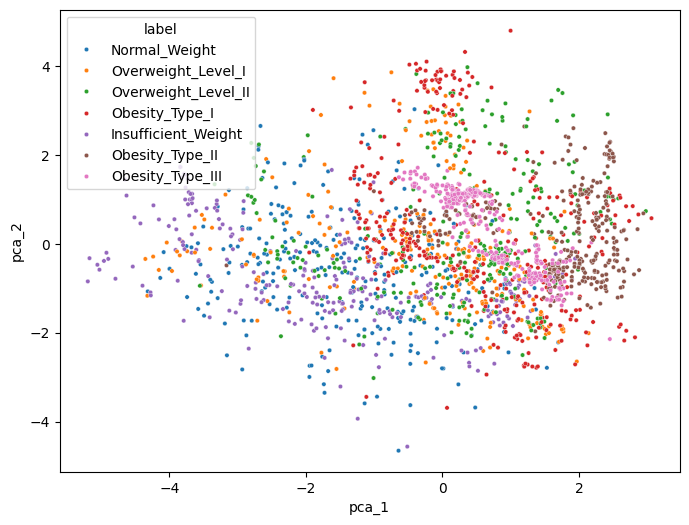

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca_1',
    y='pca_2',
    hue='label',
    palette='tab10',
    data=pca_result_df,
    s=10
)

Для візуалізації також можемо скористатися методом tSNE

In [21]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_result = tsne.fit_transform(X_std)

In [22]:
tsne

TSNE(perplexity=30, random_state=42)

In [23]:
tsne_result

array([[-41.8036  ,  19.028103],
       [-41.332775, -33.44995 ],
       [-32.762222,  15.544829],
       ...,
       [ 51.2977  , -16.51978 ],
       [ 63.39258 ,  -9.187368],
       [ 62.955032,  -9.288085]], dtype=float32)

Формуємо датафрейм для побудови графіка

In [24]:
tsne_result_df = pd.DataFrame({
    'tsne_1': tsne_result[:, 0],
    'tsne_2': tsne_result[:, 1],
    'label': y
})
tsne_result_df

,tsne_1,tsne_2,label
0,-41.803600,19.028103,Normal_Weight
1,-41.332775,-33.449951,Normal_Weight
2,-32.762222,15.544829,Normal_Weight
3,-34.581966,8.933494,Overweight_Level_I
4,-37.136139,13.208868,Overweight_Level_II
...,...,...,...
2106,47.778618,-17.917875,Obesity_Type_III
2107,51.242184,-16.485508,Obesity_Type_III
2108,51.297699,-16.519779,Obesity_Type_III
2109,63.392578,-9.187368,Obesity_Type_III


<Axes: xlabel='tsne_1', ylabel='tsne_2'>

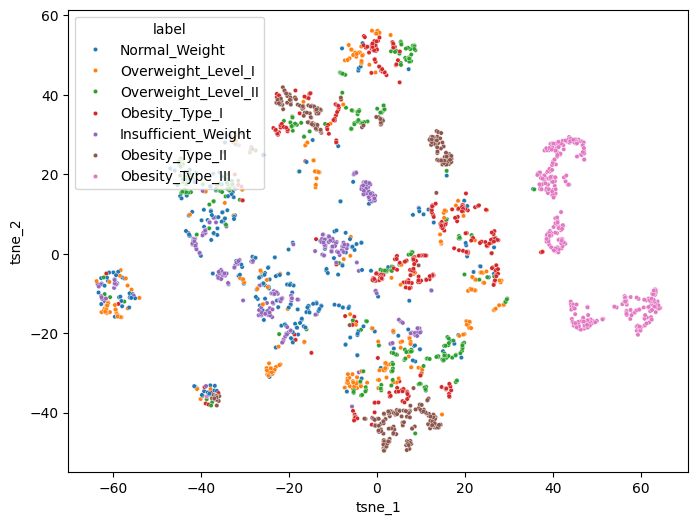

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='tsne_1',
    y='tsne_2',
    hue='label',
    palette='tab10',
    data=tsne_result_df,
    s=10
)

Тренуємо дерево рішень на повних ознаках, вимірюємо точність та час навчання.

In [89]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

In [93]:
base_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)
base_tree

DecisionTreeClassifier(random_state=42)

In [94]:
t0 = time.time()
base_tree.fit(X_train, y_train)
train_time_base = time.time() - t0

y_pred_base = base_tree.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average="weighted")

In [95]:
print(f"Accuracy (без PCA): {acc_base:.4f}")
print(f"F1-score (без PCA): {f1_base:.4f}")
print(f"Час навчання (без PCA): {train_time_base:.4f} c")

Accuracy (без PCA): 0.9125
F1-score (без PCA): 0.9134
Час навчання (без PCA): 0.0248 c


Виконуємо PCA.  

In [96]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

In [97]:
tree_pca = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)
tree_pca

DecisionTreeClassifier(random_state=42)

In [98]:
t0 = time.time()
tree_pca.fit(X_train_pca, y_train)
train_time_pca = time.time() - t0

y_pred_pca = tree_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca, average="weighted")

In [99]:
print(f"Accuracy (PCA): {acc_pca:.4f}")
print(f"F1-score (PCA): {f1_pca:.4f}")
print(f"Час навчання (PCA): {train_time_pca:.4f} c")

Accuracy (PCA): 0.4303
F1-score (PCA): 0.4278
Час навчання (PCA): 0.0178 c


Порівняння показників

In [100]:
results = pd.DataFrame([
    {"Модель": "Decision Tree (без PCA)", "Accuracy": acc_base, "F1 (weighted)": f1_base, "Час навчання, с": train_time_base},
    {"Модель": "Decision Tree (з PCA)",   "Accuracy": acc_pca,  "F1 (weighted)": f1_pca,  "Час навчання, с": train_time_pca},
])

results

,Модель,Accuracy,F1 (weighted),"Час навчання, с"
0,Decision Tree (без PCA),0.91253,0.913414,0.024833
1,Decision Tree (з PCA),0.43026,0.427836,0.017849


1. **Вплив PCA на точність.**  
   Після зниження розмірності до 2 головних компонент точність (Accuracy, F1-score) трохи знизилась порівняно з навчанням дерева рішень на повних даних.  
   Це очікувано, тому що PCA стискає інформацію, залишаючи лише напрямки з максимальною дисперсією, але не гарантує збереження ознак, що найбільше впливають на розгалуження дерева. Частина корисних для класифікації змінних могла бути втрачена.

2. **Вплив на швидкість навчання.**  
   Час навчання моделі помітно зменшився після PCA, адже ми скоротили кількість ознак із багатовимірного простору до всього двох компонент. Дерево будується швидше, оскільки йому потрібно аналізувати менше можливих розгалужень.

3. **Загальний ефект.**  
   PCA є корисним, коли важлива швидкість навчання та спрощення моделі. Але зазвичай точність дещо падає, якщо кількість компонент занадто мала, адже алгоритм втрачає частину інформації, критичної для побудови ефективних правил дерева.

Візуалізація t-SNE

In [102]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [103]:
y_codes, y_uniques = pd.factorize(y)

In [104]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_std)


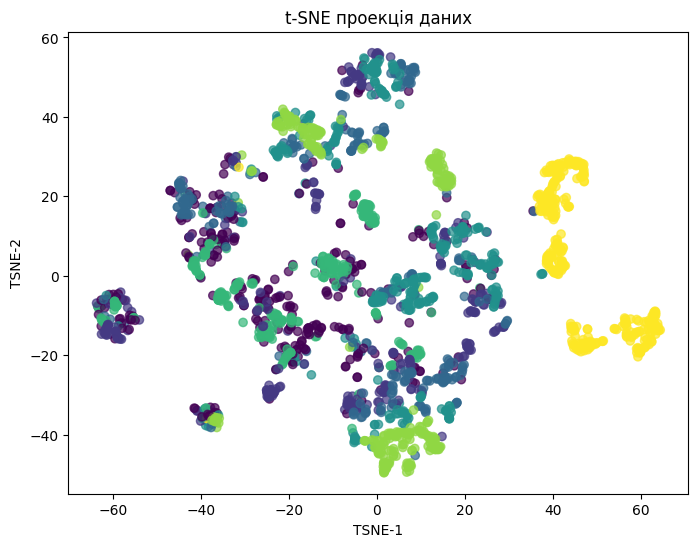

In [105]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_codes, alpha=0.7)
plt.title('t-SNE проекція даних')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.show()

На отриманому графіку видно:

Кластери точок — кожен кластер відповідає групі спостережень зі схожими ознаками (і часто однаковим класом).

Деякі кластери чітко відокремлені (наприклад, праворуч яскраво-жовта група) — це означає, що ці зразки мають дуже схожі характеристики і добре відділяються від інших класів.

Інші зони більш «змішані» — t-SNE не гарантує глобальної відстані між кластерами, тому точки різних класів можуть накладатися, якщо їхні ознаки частково збігаються.

t-SNE допомагає побачити групування даних і відокремленість класів, але глобальні відстані між кластерами не мають прямого статистичного змісту

# **Завдання 2:**
Кластерний аналіз

In [26]:
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
from sklearn.utils import shuffle

In [27]:
def recreate_image(codebook: np.ndarray, labels: np.ndarray, width: int, height: int) -> np.ndarray:
    image = codebook[labels]
    return image.reshape(height, width, -1)

In [30]:
image = Image.open('image.jpeg')
image_data_scaled = np.array(image, dtype=np.float64) / 255

Відображення зображення

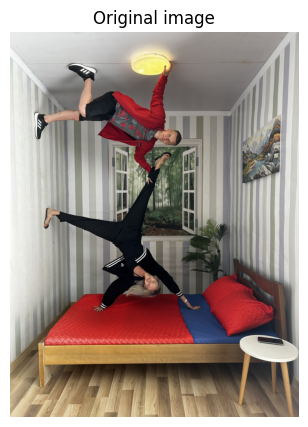

In [31]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title('Original image')
plt.imshow(image_data_scaled)
plt.show()

Зведемо зобранження у двовимірний масив для застосування K-Means


Отримуємо розміри зображення

In [32]:
img_height, img_width, img_channels = image_data_scaled.shape
assert img_channels == 3, f"Очікується 3 канали (RGB), але знайдено {img_channels}"
img_height, img_width, img_channels

(4032, 3024, 3)

Перетворюємо 3D масив (H, W, C) у 2D (H*W, C)

In [33]:
pixels_2d = np.reshape(image_data_scaled, (img_height * img_width, img_channels))
pixels_2d

array([[0.91764706, 0.9254902 , 0.92156863],
       [0.92941176, 0.9372549 , 0.93333333],
       [0.92941176, 0.9372549 , 0.93333333],
       ...,
       [0.52156863, 0.4627451 , 0.44313725],
       [0.51372549, 0.45490196, 0.43529412],
       [0.50588235, 0.44705882, 0.42745098]])

Стискання за допомогою K-Means до 64 кольорів

In [34]:
palette_size = 64

Вибірка пікселів для навчання

In [35]:
sample_pixels = shuffle(pixels_2d, random_state=0, n_samples=1000)
sample_pixels

array([[0.86666667, 0.71764706, 0.62745098],
       [0.67058824, 0.67843137, 0.66666667],
       [0.82745098, 0.66666667, 0.58039216],
       ...,
       [0.85490196, 0.85098039, 0.84313725],
       [0.66666667, 0.14901961, 0.2       ],
       [0.11764706, 0.13333333, 0.14509804]])

Навчання K-Means та прогноз міток для всіх пікселів

In [36]:
kmeans_model = KMeans(n_clusters=palette_size, random_state=0)
kmeans_model.fit(sample_pixels)
pixel_labels = kmeans_model.predict(pixels_2d)
pixel_labels

array([61,  9,  9, ...,  0,  0, 58], dtype=int32)

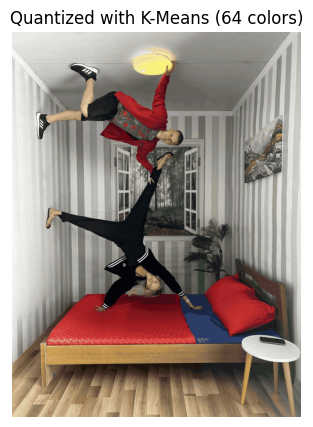

In [37]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title(f'Quantized with K-Means ({palette_size} colors)')
plt.imshow(recreate_image(kmeans_model.cluster_centers_, pixel_labels, img_width, img_height))
plt.show()

In [38]:
kmeans_model.cluster_centers_

array([[0.50043573, 0.4869281 , 0.45904139],
       [0.74098039, 0.73176471, 0.70215686],
       [0.2130719 , 0.1503268 , 0.08627451],
       [0.85958254, 0.86135357, 0.84427577],
       [0.66934046, 0.14955437, 0.16862745],
       [0.32      , 0.30901961, 0.2972549 ],
       [0.63641457, 0.62072829, 0.56246499],
       [0.04891641, 0.06439628, 0.08544892],
       [0.67764706, 0.52509804, 0.31803922],
       [0.93921569, 0.94705882, 0.93267974],
       [0.44372549, 0.44352941, 0.41411765],
       [0.10713725, 0.11356863, 0.1174902 ],
       [0.38954248, 0.03398693, 0.06579521],
       [0.75642702, 0.64357298, 0.50108932],
       [0.89411765, 0.34509804, 0.3127451 ],
       [0.3972549 , 0.38810458, 0.36496732],
       [0.54453782, 0.43865546, 0.32128852],
       [0.78071895, 0.77679739, 0.75686275],
       [0.55010893, 0.54618736, 0.51492375],
       [0.20424837, 0.23823529, 0.19901961],
       [0.82396514, 0.68409586, 0.54771242],
       [0.67300151, 0.66817496, 0.64449472],
       [0.

Стискання за допомогою K-Means до 32 кольорів

In [39]:
palette_size = 32

In [40]:
sample_pixels = shuffle(pixels_2d, random_state=0, n_samples=1000)
sample_pixels

array([[0.86666667, 0.71764706, 0.62745098],
       [0.67058824, 0.67843137, 0.66666667],
       [0.82745098, 0.66666667, 0.58039216],
       ...,
       [0.85490196, 0.85098039, 0.84313725],
       [0.66666667, 0.14901961, 0.2       ],
       [0.11764706, 0.13333333, 0.14509804]])

In [41]:
kmeans_model = KMeans(n_clusters=palette_size, random_state=0)
kmeans_model.fit(sample_pixels)
pixel_labels = kmeans_model.predict(pixels_2d)
pixel_labels

array([28, 28, 28, ...,  0,  0,  0], dtype=int32)

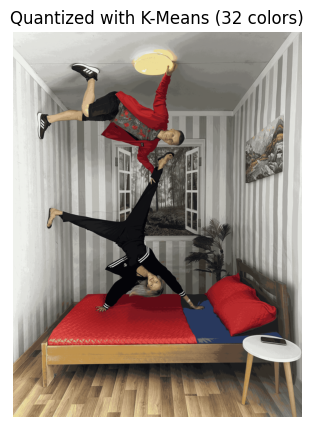

In [42]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title(f'Quantized with K-Means ({palette_size} colors)')
plt.imshow(recreate_image(kmeans_model.cluster_centers_, pixel_labels, img_width, img_height))
plt.show()

In [43]:
kmeans_model.cluster_centers_

array([[0.47809524, 0.46901961, 0.44705882],
       [0.73664488, 0.73237473, 0.70535948],
       [0.20721063, 0.18456673, 0.15838077],
       [0.71586453, 0.16737968, 0.17593583],
       [0.61425155, 0.60602582, 0.58096604],
       [0.8831244 , 0.88666024, 0.86936676],
       [0.36336429, 0.36016512, 0.33550052],
       [0.06470588, 0.06606335, 0.0760181 ],
       [0.68776844, 0.58338002, 0.42726424],
       [0.51101056, 0.40844646, 0.30030166],
       [0.93053221, 0.87338936, 0.60392157],
       [0.87058824, 0.3037037 , 0.28235294],
       [0.36887255, 0.04803922, 0.08578431],
       [0.83205456, 0.83256607, 0.81696505],
       [0.26022409, 0.25098039, 0.22717087],
       [0.5047619 , 0.0952381 , 0.1254902 ],
       [0.52847806, 0.52356054, 0.4961718 ],
       [0.66729055, 0.66336898, 0.64661319],
       [0.11510957, 0.11649366, 0.12041522],
       [0.74621849, 0.57385621, 0.30756303],
       [0.83621684, 0.72479815, 0.57693195],
       [0.15729847, 0.22004357, 0.36688453],
       [0.

Стискання за допомогою K-Means до 16 кольорів

In [44]:
palette_size = 16

In [45]:
sample_pixels = shuffle(pixels_2d, random_state=0, n_samples=1000)
sample_pixels

array([[0.86666667, 0.71764706, 0.62745098],
       [0.67058824, 0.67843137, 0.66666667],
       [0.82745098, 0.66666667, 0.58039216],
       ...,
       [0.85490196, 0.85098039, 0.84313725],
       [0.66666667, 0.14901961, 0.2       ],
       [0.11764706, 0.13333333, 0.14509804]])

In [46]:
kmeans_model = KMeans(n_clusters=palette_size, random_state=0)
kmeans_model.fit(sample_pixels)
pixel_labels = kmeans_model.predict(pixels_2d)
pixel_labels

array([4, 4, 4, ..., 0, 0, 0], dtype=int32)

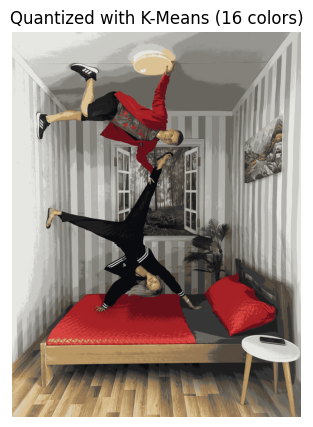

In [47]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title(f'Quantized with K-Means ({palette_size} colors)')
plt.imshow(recreate_image(kmeans_model.cluster_centers_, pixel_labels, img_width, img_height))
plt.show()

In [48]:
kmeans_model.cluster_centers_

array([[0.51452433, 0.50675381, 0.48010167],
       [0.70307366, 0.69841017, 0.67493376],
       [0.04213406, 0.04377565, 0.05736434],
       [0.65010004, 0.13229292, 0.14581833],
       [0.90344953, 0.90798838, 0.89081336],
       [0.34030501, 0.29716776, 0.24673203],
       [0.72634581, 0.59393939, 0.394082  ],
       [0.1250342 , 0.12083903, 0.12156863],
       [0.4114795 , 0.39967914, 0.36987522],
       [0.59441474, 0.5862547 , 0.56502278],
       [0.58870588, 0.46752941, 0.33019608],
       [0.41019608, 0.06290196, 0.10133333],
       [0.84901961, 0.27614379, 0.25882353],
       [0.86101961, 0.76345098, 0.58337255],
       [0.21745483, 0.21376394, 0.21322568],
       [0.7977591 , 0.79614846, 0.77923669]])

Стискання за допомогою K-Means до 8 кольорів

In [49]:
palette_size = 8

In [50]:
sample_pixels = shuffle(pixels_2d, random_state=0, n_samples=1000)
sample_pixels

array([[0.86666667, 0.71764706, 0.62745098],
       [0.67058824, 0.67843137, 0.66666667],
       [0.82745098, 0.66666667, 0.58039216],
       ...,
       [0.85490196, 0.85098039, 0.84313725],
       [0.66666667, 0.14901961, 0.2       ],
       [0.11764706, 0.13333333, 0.14509804]])

In [51]:
kmeans_model = KMeans(n_clusters=palette_size, random_state=0)
kmeans_model.fit(sample_pixels)
pixel_labels = kmeans_model.predict(pixels_2d)
pixel_labels

array([4, 4, 4, ..., 5, 5, 5], dtype=int32)

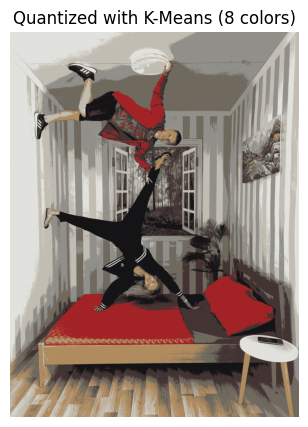

In [52]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title(f'Quantized with K-Means ({palette_size} colors)')
plt.imshow(recreate_image(kmeans_model.cluster_centers_, pixel_labels, img_width, img_height))
plt.show()

In [53]:
kmeans_model.cluster_centers_

array([[0.57027057, 0.56319422, 0.53997152],
       [0.76156863, 0.744694  , 0.70229352],
       [0.07983539, 0.07494553, 0.08448318],
       [0.64296424, 0.13564014, 0.14965398],
       [0.88598106, 0.88854208, 0.86893424],
       [0.43566105, 0.41256737, 0.37245729],
       [0.69259962, 0.54556188, 0.37216951],
       [0.26343954, 0.20772059, 0.20122549]])

# **Завдання 3:**
Обробка та класифікація текстових даних

In [54]:
from nltk import download
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from string import punctuation
import re

Завантажуємо стоп-слова

In [55]:
download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Проводимо передобробку тексту

In [56]:
def preprocess_text(text_line, stopword_list):
    if not isinstance(text_line, str):
        text_line = "" if pd.isna(text_line) else str(text_line)
    cleaned = text_line.lower()
    cleaned = re.sub(r'@\S+', ' ', cleaned)
    cleaned = re.sub(r'https*\S+', ' ', cleaned)
    cleaned = re.sub(r'#\S+', ' ', cleaned)
    cleaned = re.sub(r'\d', ' ', cleaned)
    cleaned = re.sub(r'[%s]' % re.escape(punctuation), ' ', cleaned)
    cleaned = re.sub(r'\n', ' ', cleaned)
    cleaned = re.sub(r'\s{2,}', ' ', cleaned)

    cleaned = ' '.join(
        token for token in cleaned.split(' ') if token and token not in stopword_list
    )
    return cleaned


Для цього завдання було обрано датасет відгуків про додаток Spotify з Google Play Store за проміжок Січня-Липня 2022 року. Датасет містить текст відгуку та мітку позитивний/негативний (емоційне забарвлення).

Посилання: https://www.kaggle.com/datasets/alexandrakim2201/spotify-dataset

Проведемо загальний огляд датасету.

In [57]:
spotify_reviews = pd.read_csv('spotify.csv')
spotify_reviews

,Review,label
0,"Great music service, the audio is high quality...",POSITIVE
1,Please ignore previous negative rating. This a...,POSITIVE
2,"This pop-up ""Get the best Spotify experience o...",NEGATIVE
3,Really buggy and terrible to use as of recently,NEGATIVE
4,Dear Spotify why do I get songs that I didn't ...,NEGATIVE
...,...,...
52697,Yes the best,POSITIVE
52698,Spotify won my heart in Feb 2024 You won my he...,POSITIVE
52699,I tried to open the app and it wont open I res...,POSITIVE
52700,Good,POSITIVE


In [58]:
spotify_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52702 entries, 0 to 52701
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  52686 non-null  object
 1   label   52702 non-null  object
dtypes: object(2)
memory usage: 823.6+ KB


In [59]:
spotify_reviews.shape

(52702, 2)

In [60]:
text_col = spotify_reviews.columns[0]
label_col = spotify_reviews.columns[1]
text_col, label_col

('Review', 'label')

In [61]:
spotify_reviews.columns

Index(['Review', 'label'], dtype='object')

In [62]:
spotify_reviews.head()

,Review,label
0,"Great music service, the audio is high quality...",POSITIVE
1,Please ignore previous negative rating. This a...,POSITIVE
2,"This pop-up ""Get the best Spotify experience o...",NEGATIVE
3,Really buggy and terrible to use as of recently,NEGATIVE
4,Dear Spotify why do I get songs that I didn't ...,NEGATIVE


In [63]:
from collections import Counter
label_counts = Counter(spotify_reviews[label_col])
label_counts

Counter({'POSITIVE': 23279, 'NEGATIVE': 29423})

Очистимо тексти відгуків від пунктуації, чисел та загальних для мови неінформативних слів

In [64]:
english_stopwords = stopwords.words('english')
english_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [65]:
spotify_reviews[text_col] = spotify_reviews[text_col].map(
    lambda review: preprocess_text(review, english_stopwords)
)
spotify_reviews

,Review,label
0,great music service audio high quality app eas...,POSITIVE
1,please ignore previous negative rating app sup...,POSITIVE
2,pop get best spotify experience android annoyi...,NEGATIVE
3,really buggy terrible use recently,NEGATIVE
4,dear spotify get songs put playlist shuffle play,NEGATIVE
...,...,...
52697,yes best,POSITIVE
52698,spotify heart feb heart music lyrics language ...,POSITIVE
52699,tried open app wont open restarted phone ill t...,POSITIVE
52700,good,POSITIVE


In [66]:
spotify_reviews.head()

,Review,label
0,great music service audio high quality app eas...,POSITIVE
1,please ignore previous negative rating app sup...,POSITIVE
2,pop get best spotify experience android annoyi...,NEGATIVE
3,really buggy terrible use recently,NEGATIVE
4,dear spotify get songs put playlist shuffle play,NEGATIVE


Візуалізація: зобразимо для обох класів Хмари Слів

In [67]:
from wordcloud import WordCloud
def create_wordcloud(df, class_label):
    all_text = ' '.join(
        review.lower()
        for review in df[df[label_col] == class_label][text_col]
    )
    if len(all_text.strip()) == 0:
        return

    wc = WordCloud(width=600, height=400, background_color="white").generate(all_text)
    plt.figure(figsize=(8, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for '{class_label}'")
    plt.show()

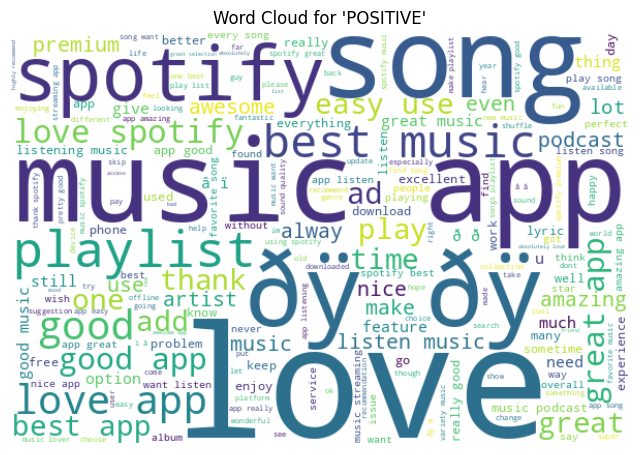

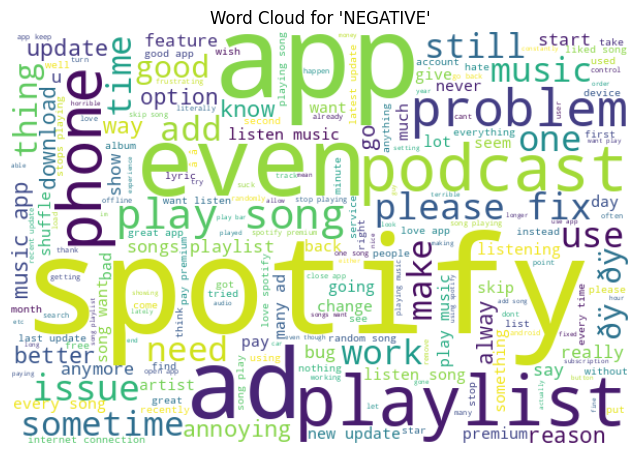

In [68]:
for class_name in spotify_reviews[label_col].unique():
    create_wordcloud(spotify_reviews, class_name)

Розіб'ємо датасет на тренувальні дані та дані для перевірки

Розділяємо дані на тренувальні та тестові

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    spotify_reviews[text_col].fillna("").astype(str),
    spotify_reviews[label_col],
    test_size=0.2,
    random_state=42,
    stratify=spotify_reviews[label_col] if spotify_reviews[label_col].nunique() > 1 else None
)
X_train

,Review
2700,spotify good place listen music best without p...
20388,used great ads intense blth visual every rd so...
17057,taking wifi audio youtube running audio takes ...
12614,love look want gives song might like
52613,sensational
...,...
37516,last update sudden app keeps turning reason ha...
23867,place listen music ðÿž¶
18159,terrible podcasts randomly skips episodes ads ...
26461,changed phones use customer care gave excuses ...


In [70]:
X_test

,Review
46075,amazing service great playlists would recommend
11818,allow review songs downloading need revise
17640,great deleted one playlist course happens one ...
37073,new update abysmal music plays controls music ...
36361,use app every day numerous times per day curre...
...,...
40425,premium order actual ui ever since canceled pr...
39158,bug present update song display bar showing
20964,filtering podcasts sorting seem lumped togethe...
26098,app amazing use lot type song always give resu...


In [71]:
y_train

,label
2700,POSITIVE
20388,NEGATIVE
17057,NEGATIVE
12614,POSITIVE
52613,POSITIVE
...,...
37516,NEGATIVE
23867,NEGATIVE
18159,NEGATIVE
26461,NEGATIVE


In [72]:
y_test

,label
46075,POSITIVE
11818,NEGATIVE
17640,POSITIVE
37073,NEGATIVE
36361,NEGATIVE
...,...
40425,NEGATIVE
39158,NEGATIVE
20964,NEGATIVE
26098,NEGATIVE


In [73]:
len(X_train), len(y_train), len(X_test), len(y_test)

(42161, 42161, 10541, 10541)

Векторизуємо дані за допомогою TfidfVectorizer

Таким чином перетворимо nекстові дані в оцінку та підготуємо дані для тренування моделі.

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.8)
tfidf_vectorizer

TfidfVectorizer(max_df=0.8)

Навчаємо векторизатор на тренувальних даних та перетворюємо тексти в матрицю ознак

In [75]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 556651 stored elements and shape (42161, 18931)>

Перетворюємо тестові дані за вже навченим векторизатором

In [76]:
X_test_tfidf = tfidf_vectorizer.transform(X_test)
X_test_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 136341 stored elements and shape (10541, 18931)>

Модель 1: Наївний баєсівський класифікатор

In [77]:
from sklearn.naive_bayes import MultinomialNB

Підберемо параметр згладжування, що дасть найменшу помилку (це не обовʼязково, було просто цікаво)

In [78]:
error_rate = {}
for a in [x / 10.0 for x in range(1, 20)]:
    nb_trial = MultinomialNB(alpha=a)
    nb_trial.fit(X_train_tfidf, y_train)
    pred_a = nb_trial.predict(X_test_tfidf)
    error_rate[a] = np.mean(pred_a != y_test)

error_rate

{0.1: np.float64(0.14154254814533726),
 0.2: np.float64(0.139929797931885),
 0.3: np.float64(0.13955032729342567),
 0.4: np.float64(0.14059387154918887),
 0.5: np.float64(0.14059387154918887),
 0.6: np.float64(0.1411630775068779),
 0.7: np.float64(0.14106820984726307),
 0.8: np.float64(0.1408784745280334),
 0.9: np.float64(0.14106820984726307),
 1.0: np.float64(0.14182715112418176),
 1.1: np.float64(0.14182715112418176),
 1.2: np.float64(0.1426809600607153),
 1.3: np.float64(0.14306043069917465),
 1.4: np.float64(0.14457831325301204),
 1.5: np.float64(0.14457831325301204),
 1.6: np.float64(0.1452423868703159),
 1.7: np.float64(0.14552698984916043),
 1.8: np.float64(0.14562185750877527),
 1.9: np.float64(0.1461910634664643)}

In [79]:
alph = min(error_rate, key=error_rate.get)
alph, error_rate[alph]

(0.3, np.float64(0.13955032729342567))

Навчання та застосування моделі до тестового набору даних.

In [80]:
nb = MultinomialNB(alpha=alph)
nb.fit(X_train_tfidf, y_train)

MultinomialNB(alpha=0.3)

In [81]:
y_pred = nb.predict(X_test_tfidf)
y_pred

array(['POSITIVE', 'NEGATIVE', 'NEGATIVE', ..., 'NEGATIVE', 'POSITIVE',
       'NEGATIVE'], dtype='<U8')

In [82]:
from sklearn.metrics import accuracy_score, classification_report

In [83]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    NEGATIVE       0.86      0.90      0.88      5885
    POSITIVE       0.86      0.81      0.84      4656

    accuracy                           0.86     10541
   macro avg       0.86      0.86      0.86     10541
weighted avg       0.86      0.86      0.86     10541

[[5293  592]
 [ 879 3777]]


Модель 2: Логістична Регресія

Ця модель застосовна, так як наші дані мають "бінарні мітки". Іншими словами, їх можна замінити на 0 і 1.

In [84]:
from sklearn.linear_model import LogisticRegression

In [85]:
classifier = LogisticRegression()
classifier.fit(X_train_tfidf, y_train)


LogisticRegression()

In [86]:
lr_predict = classifier.predict(X_test_tfidf)
lr_predict

array(['POSITIVE', 'NEGATIVE', 'POSITIVE', ..., 'NEGATIVE', 'POSITIVE',
       'NEGATIVE'], dtype=object)

In [87]:
print(classification_report(y_test, lr_predict))
print(confusion_matrix(y_test, lr_predict))

              precision    recall  f1-score   support

    NEGATIVE       0.89      0.90      0.90      5885
    POSITIVE       0.88      0.86      0.87      4656

    accuracy                           0.88     10541
   macro avg       0.88      0.88      0.88     10541
weighted avg       0.88      0.88      0.88     10541

[[5320  565]
 [ 666 3990]]
